El binario (0/1) tiene dos problemas: el 99% de las filas son 0 y el modelo aprende a decir siempre 0, y no puedes ajustar el umbral de alerta después sin reentrenar.

Usamos hours_to_fault: cuántas horas faltan al próximo fallo de esa familia.

Si no hay fallo en las próximas N horas → NaN (estado normal)
Si hay fallo en las próximas N horas → el número de horas (ej: 47.3)
Luego is_pre_fault = hours_to_fault <= lead_time → esto sí es binario, pero calculado Paso 2.1 — Define familias y lead times

In [7]:
import os
import pandas as pd
import numpy as np

base_dir = os.path.dirname(os.getcwd())

# ==============================================================================
# 1. CARGAR DATOS
# ==============================================================================
telem = pd.read_parquet(os.path.join(base_dir, "data", "silver", "turbine_1_telemetry_clean.parquet"))
targets = pd.read_parquet(os.path.join(base_dir, "data", "silver", "fault_targets_grouped.parquet"))

telem = telem.sort_values("timestamp").reset_index(drop=True)

# ==============================================================================
# 2. CONFIGURACIÓN DE FAMILIAS Y LEAD TIMES
# ==============================================================================
FAULT_FAMILIES = {
    "yaw_cable":   {"lead_hours": 168},  # 7 días
    "brake_hydro": {"lead_hours": 120},  # 5 días
    "generator":   {"lead_hours": 120},  # 5 días
    "pitch_bat":   {"lead_hours": 336},  # 14 días
}

# ==============================================================================
# 3. FUNCIÓN DE ETIQUETADO
# ==============================================================================
def label_family(telem_df, fault_times_sorted, lead_hours):
    """
    Para cada fila de telemetría, calcula horas al próximo fallo de la familia.
    Si no hay fallo en las próximas lead_hours → NaN
    """
    ts_array = telem_df["timestamp"].values.astype("datetime64[ns]")
    fault_array = np.array(fault_times_sorted, dtype="datetime64[ns]")
    
    hours_arr = np.full(len(ts_array), np.nan)
    
    for i, ts in enumerate(ts_array):
        future_mask = fault_array > ts
        if not future_mask.any():
            continue
        next_fault = fault_array[future_mask][0]
        delta_h = (next_fault - ts) / np.timedelta64(1, "h")
        if delta_h <= lead_hours:
            hours_arr[i] = delta_h
    
    return hours_arr

# ==============================================================================
# 4. APLICAR PARA CADA FAMILIA
# ==============================================================================
for family, cfg in FAULT_FAMILIES.items():
    
    fault_times = (targets[targets["family"] == family]
                   ["timestamp"]
                   .sort_values()
                   .values)
    
    hours = label_family(telem, fault_times, cfg["lead_hours"])
    telem[f"hours_to_{family}"] = hours
    telem[f"is_pre_{family}"] = (~np.isnan(hours))
    

# ==============================================================================
# 5. GUARDAR DATASET ETIQUETADO
# ==============================================================================
output_path = os.path.join(base_dir, "data", "silver", "dataset_labeled.parquet")
telem.to_parquet(output_path, index=False)

rel_path = os.path.relpath(output_path, base_dir)
print(f"\n✅ Dataset etiquetado guardado en ./{rel_path}")

# Resumen de columnas creadas
target_cols = [c for c in telem.columns if c.startswith("hours_to_") or c.startswith("is_pre_")]
print(f"\nColumnas target creadas: {len(target_cols)}")
for col in sorted(target_cols):
    print(f"  - {col}")

# Resumen final por familia
print(f"\n{'='*60}")
print("RESUMEN DE ETIQUETADO")
print(f"{'='*60}")
for family in FAULT_FAMILIES.keys():
    n_pre = telem[f"is_pre_{family}"].sum()
    pct = 100 * n_pre / len(telem)
    print(f"{family:12}: {n_pre:>6,} filas pre-fallo ({pct:>5.2f}%)")



✅ Dataset etiquetado guardado en ./data/silver/dataset_labeled.parquet

Columnas target creadas: 8
  - hours_to_brake_hydro
  - hours_to_generator
  - hours_to_pitch_bat
  - hours_to_yaw_cable
  - is_pre_brake_hydro
  - is_pre_generator
  - is_pre_pitch_bat
  - is_pre_yaw_cable

RESUMEN DE ETIQUETADO
yaw_cable   : 100,065 filas pre-fallo (47.56%)
brake_hydro : 21,185 filas pre-fallo (10.07%)
generator   : 22,272 filas pre-fallo (10.59%)
pitch_bat   : 28,753 filas pre-fallo (13.67%)


In [8]:
# Ver que el etiquetado tiene sentido
family = "yaw_cable"
print(f"Primeras filas pre-{family}:")
print(telem[telem[f"is_pre_{family}"]][["timestamp", f"hours_to_{family}"]].head(10))

Primeras filas pre-yaw_cable:
               timestamp  hours_to_yaw_cable
9737 2018-03-09 13:50:00          168.000000
9738 2018-03-09 14:00:00          167.833333
9739 2018-03-09 14:10:00          167.666667
9740 2018-03-09 14:20:00          167.500000
9741 2018-03-09 14:30:00          167.333333
9742 2018-03-09 14:40:00          167.166667
9743 2018-03-09 14:50:00          167.000000
9744 2018-03-09 15:00:00          166.833333
9745 2018-03-09 15:10:00          166.666667
9746 2018-03-09 15:20:00          166.500000


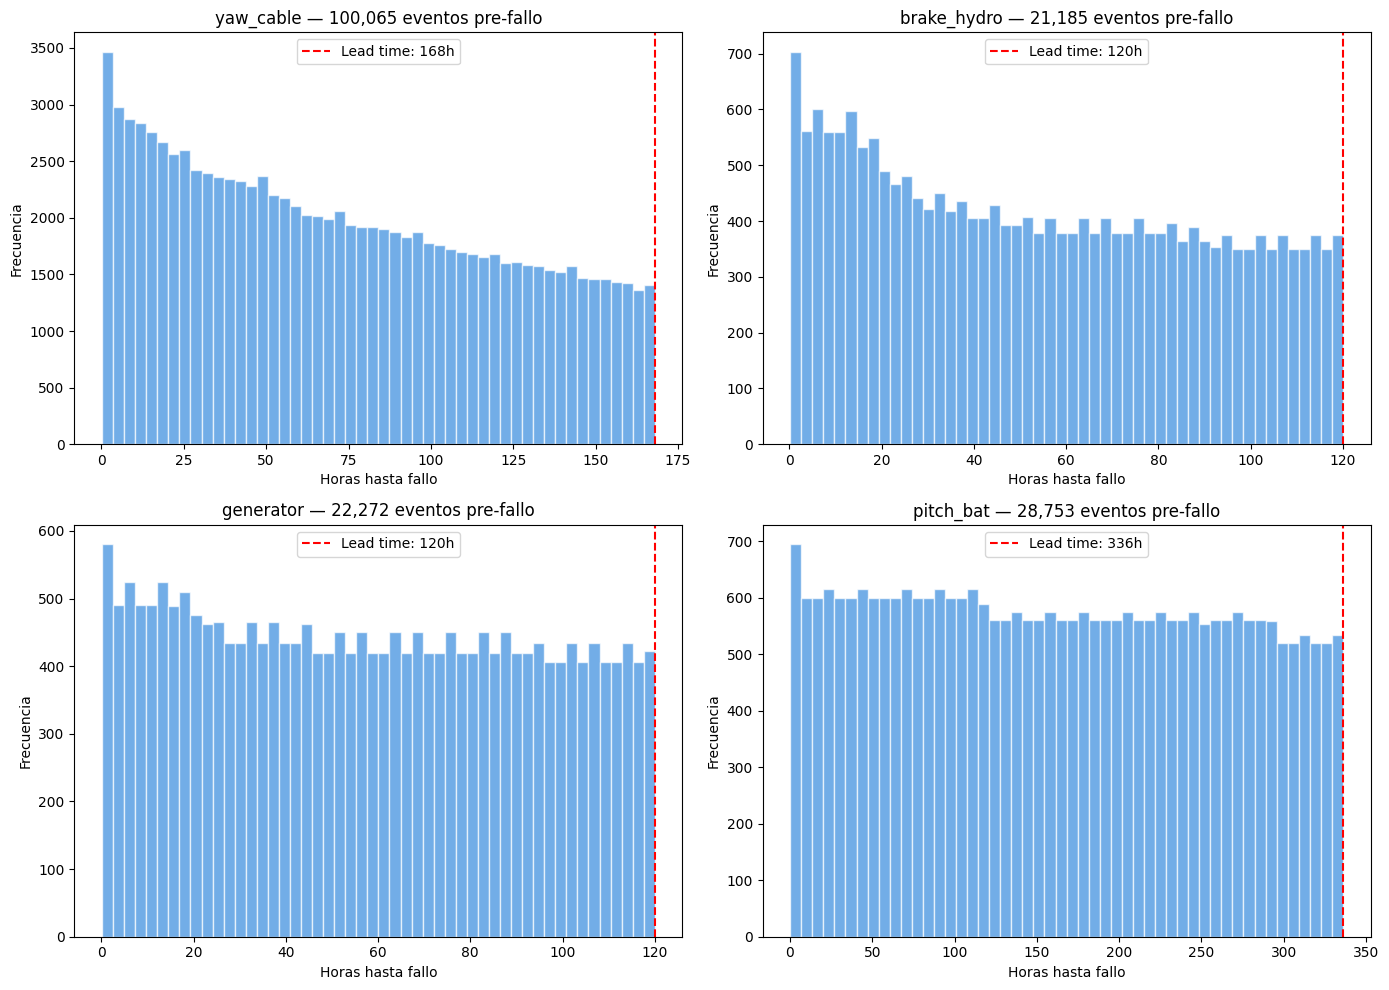

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, family in enumerate(FAULT_FAMILIES.keys()):
    ax = axes[idx]
    
    # Histograma de hours_to_fault
    hours_col = f"hours_to_{family}"
    data = telem[hours_col].dropna()
    
    ax.hist(data, bins=50, color="#378ADD", alpha=0.7, edgecolor="white")
    ax.axvline(FAULT_FAMILIES[family]["lead_hours"], color="red", linestyle="--", 
               label=f"Lead time: {FAULT_FAMILIES[family]['lead_hours']}h")
    ax.set_xlabel("Horas hasta fallo")
    ax.set_ylabel("Frecuencia")
    ax.set_title(f"{family} — {len(data):,} eventos pre-fallo")
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(base_dir, "data", "silver", "labeling_distribution.png"), dpi=150)
plt.show()

Fallo de ejemplo: 2018-03-16 13:50:00
Familia: yaw_cable
Filas en ventana: 1453
Filas etiquetadas como pre-fallo: 1008


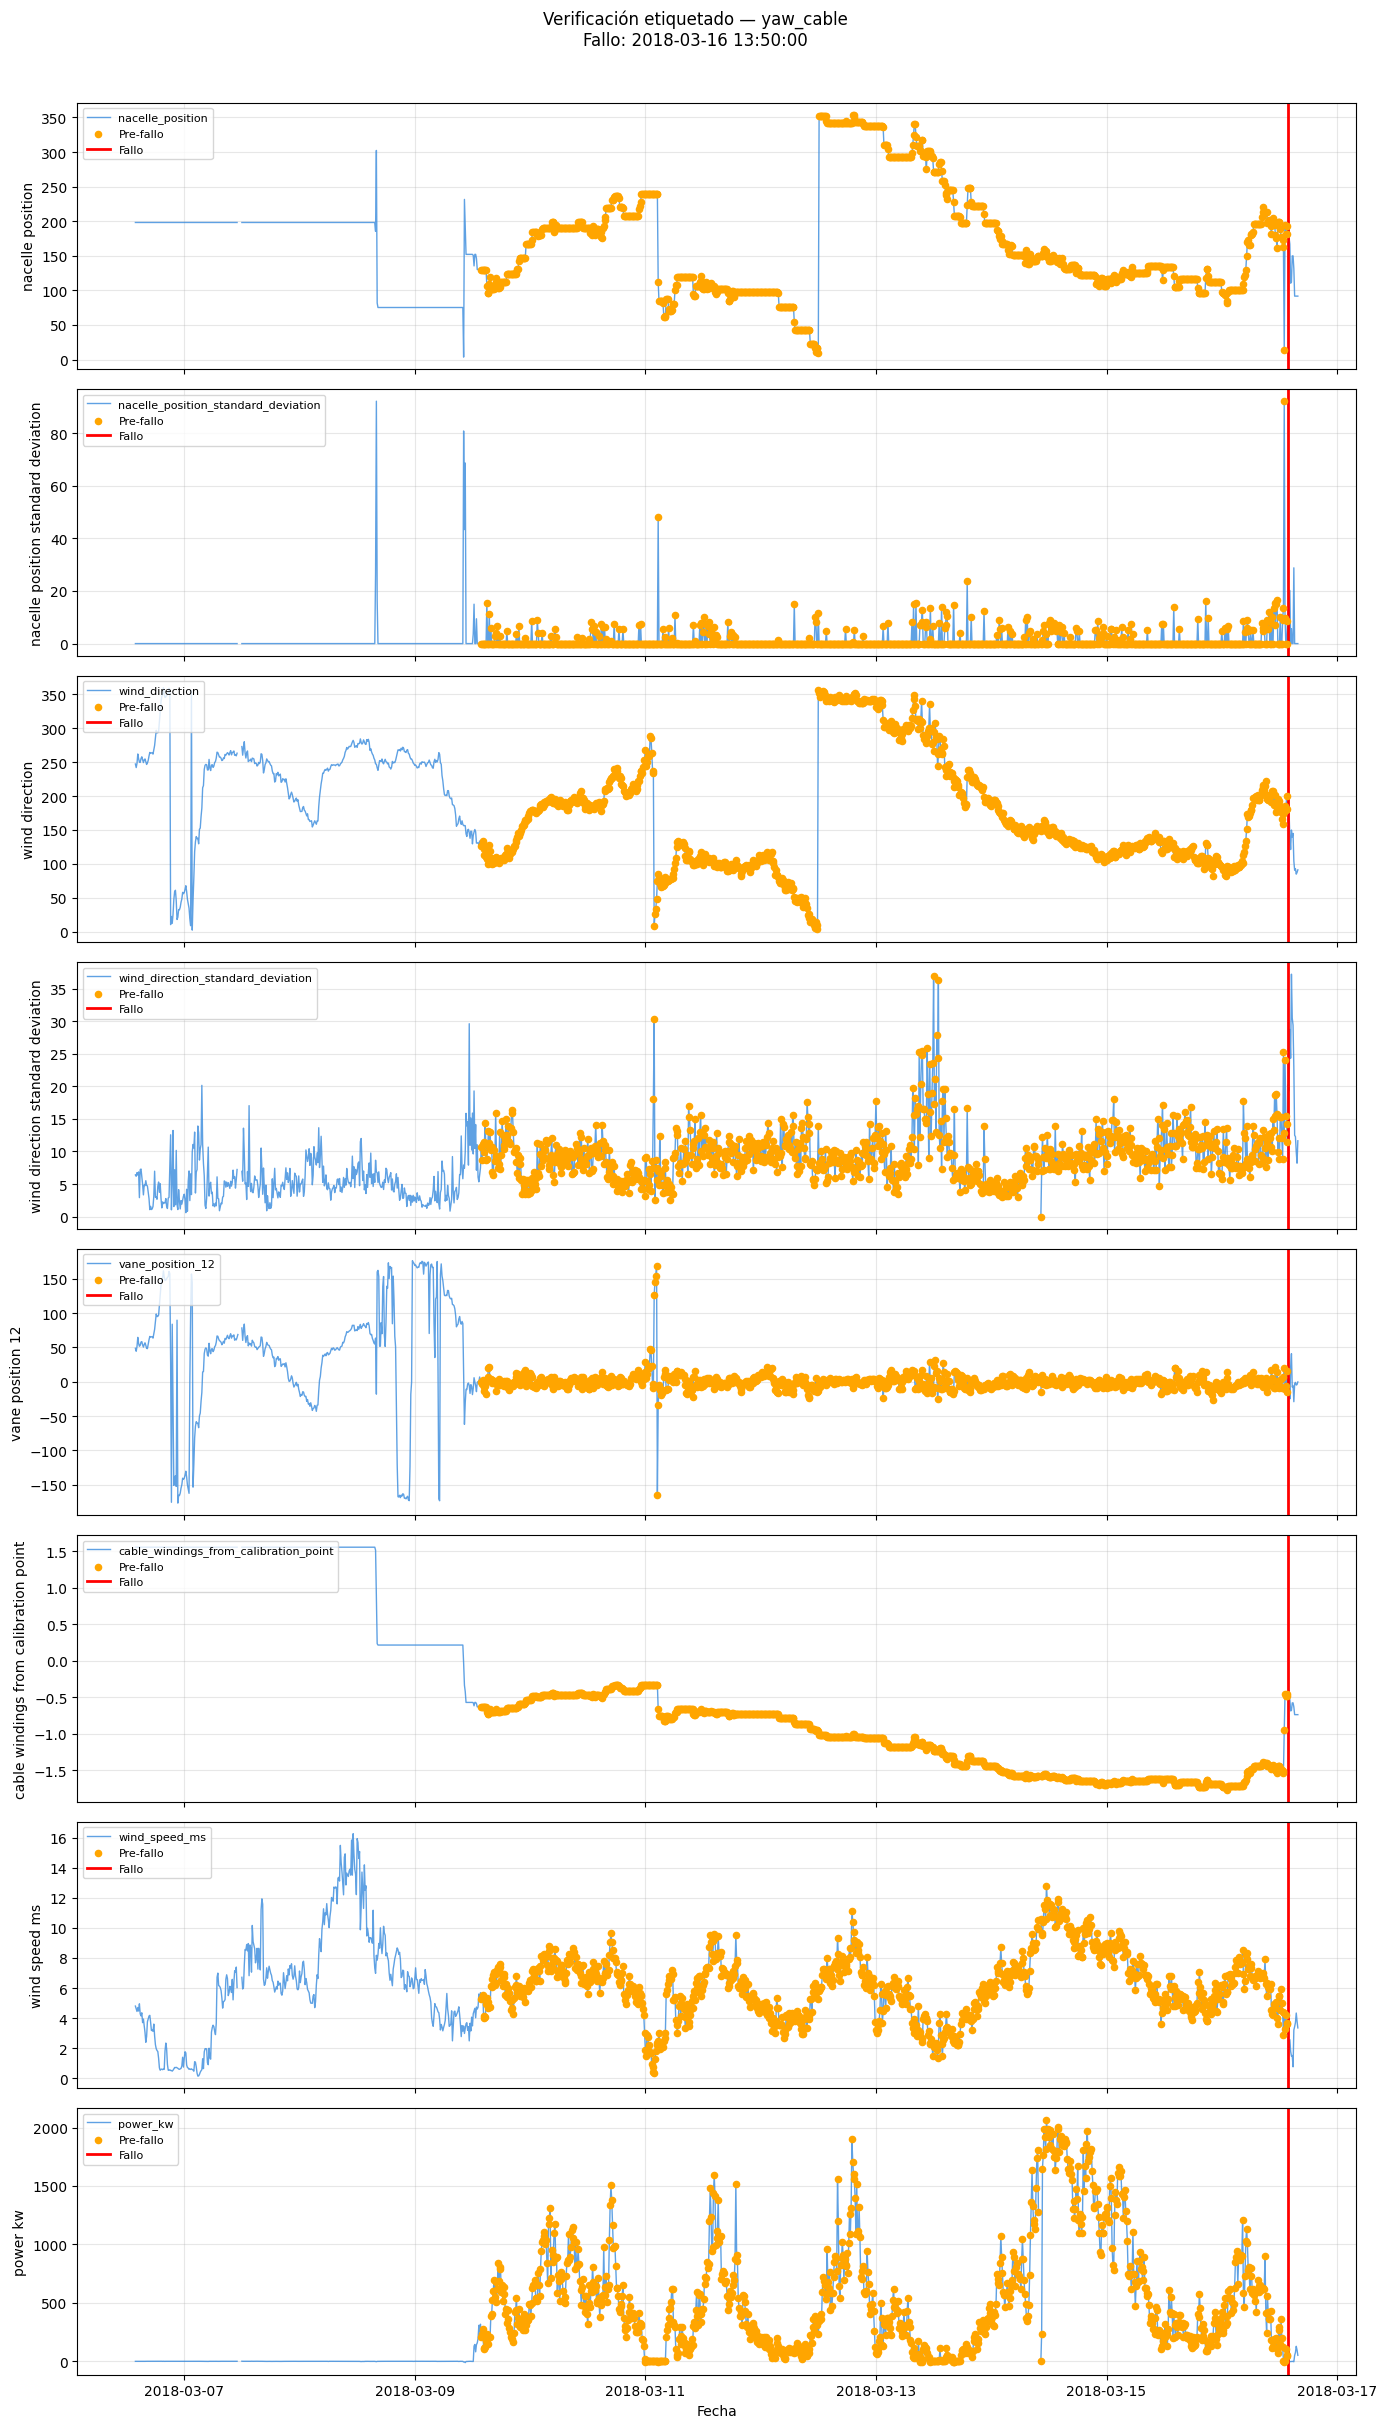


✅ Guardado: ./docs/images/labeling_check_yaw_cable.png
   Sensores: 8
   Pre-fallos: 1008 puntos


In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt

base_dir = os.path.dirname(os.getcwd())

# Cargar datos
telem = pd.read_parquet(os.path.join(base_dir, "data", "silver", "dataset_labeled.parquet"))
targets = pd.read_parquet(os.path.join(base_dir, "data", "silver", "fault_targets_grouped.parquet"))

# ==============================================================================
# CONFIGURACIÓN: familia y sensores
# ==============================================================================
family = "yaw_cable"

SENSORS_YAW_CABLE = [
    "nacelle_position",
    "nacelle_position_standard_deviation",
    "wind_direction",
    "wind_direction_standard_deviation",
    "vane_position_12",
    "cable_windings_from_calibration_point",
    "wind_speed_ms",
    "power_kw",
]

# Crear directorio docs/images si no existe
docs_images_dir = os.path.join(base_dir, "docs", "images")
os.makedirs(docs_images_dir, exist_ok=True)

# ==============================================================================
# TOMAR FALLO DE EJEMPLO
# ==============================================================================
fault_sample = targets[targets["family"] == family]["timestamp"].iloc[0]

print(f"Fallo de ejemplo: {fault_sample}")
print(f"Familia: {family}")

# Ventana de 10 días antes + 2 horas después
window_start = fault_sample - pd.Timedelta(days=10)
window_end = fault_sample + pd.Timedelta(hours=2)

window = telem[(telem["timestamp"] >= window_start) & (telem["timestamp"] <= window_end)].copy()

print(f"Filas en ventana: {len(window)}")
print(f"Filas etiquetadas como pre-fallo: {window[f'is_pre_{family}'].sum()}")

# ==============================================================================
# VISUALIZAR TODOS LOS SENSORES
# ==============================================================================
n_sensors = len(SENSORS_YAW_CABLE)
fig, axes = plt.subplots(n_sensors, 1, figsize=(14, 3 * n_sensors), sharex=True)

if n_sensors == 1:
    axes = [axes]

for idx, sensor in enumerate(SENSORS_YAW_CABLE):
    ax = axes[idx]
    
    if sensor not in window.columns:
        ax.set_title(f"{sensor} — NO ENCONTRADO EN DATASET")
        ax.text(0.5, 0.5, f"Columna '{sensor}' no existe", 
                ha="center", va="center", transform=ax.transAxes)
        continue
    
    # Línea del sensor
    ax.plot(window["timestamp"], window[sensor], 
            color="#378ADD", linewidth=1, alpha=0.8, label=sensor)
    
    # Marcar pre-fallo
    pre_window = window[window[f"is_pre_{family}"]]
    if len(pre_window) > 0:
        ax.scatter(pre_window["timestamp"], pre_window[sensor],
                   color="orange", s=20, label="Pre-fallo", zorder=5)
    
    # Línea del fallo
    ax.axvline(fault_sample, color="red", linewidth=2, label="Fallo")
    
    ax.set_ylabel(sensor.replace("_", " "))
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Fecha")
fig.suptitle(f"Verificación etiquetado — {family}\nFallo: {fault_sample}", 
             fontsize=12, y=1.01)

plt.tight_layout()

# Guardar
output_path = os.path.join(docs_images_dir, f"labeling_check_{family}.png")
plt.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()

rel_path = os.path.relpath(output_path, base_dir)
print(f"\n✅ Guardado: ./{rel_path}")
print(f"   Sensores: {n_sensors}")
print(f"   Pre-fallos: {window[f'is_pre_{family}'].sum()} puntos")

Fallo de ejemplo: 2018-01-11 15:00:00
Familia: brake_hydro
Filas en ventana: 1453
Filas etiquetadas como pre-fallo: 720


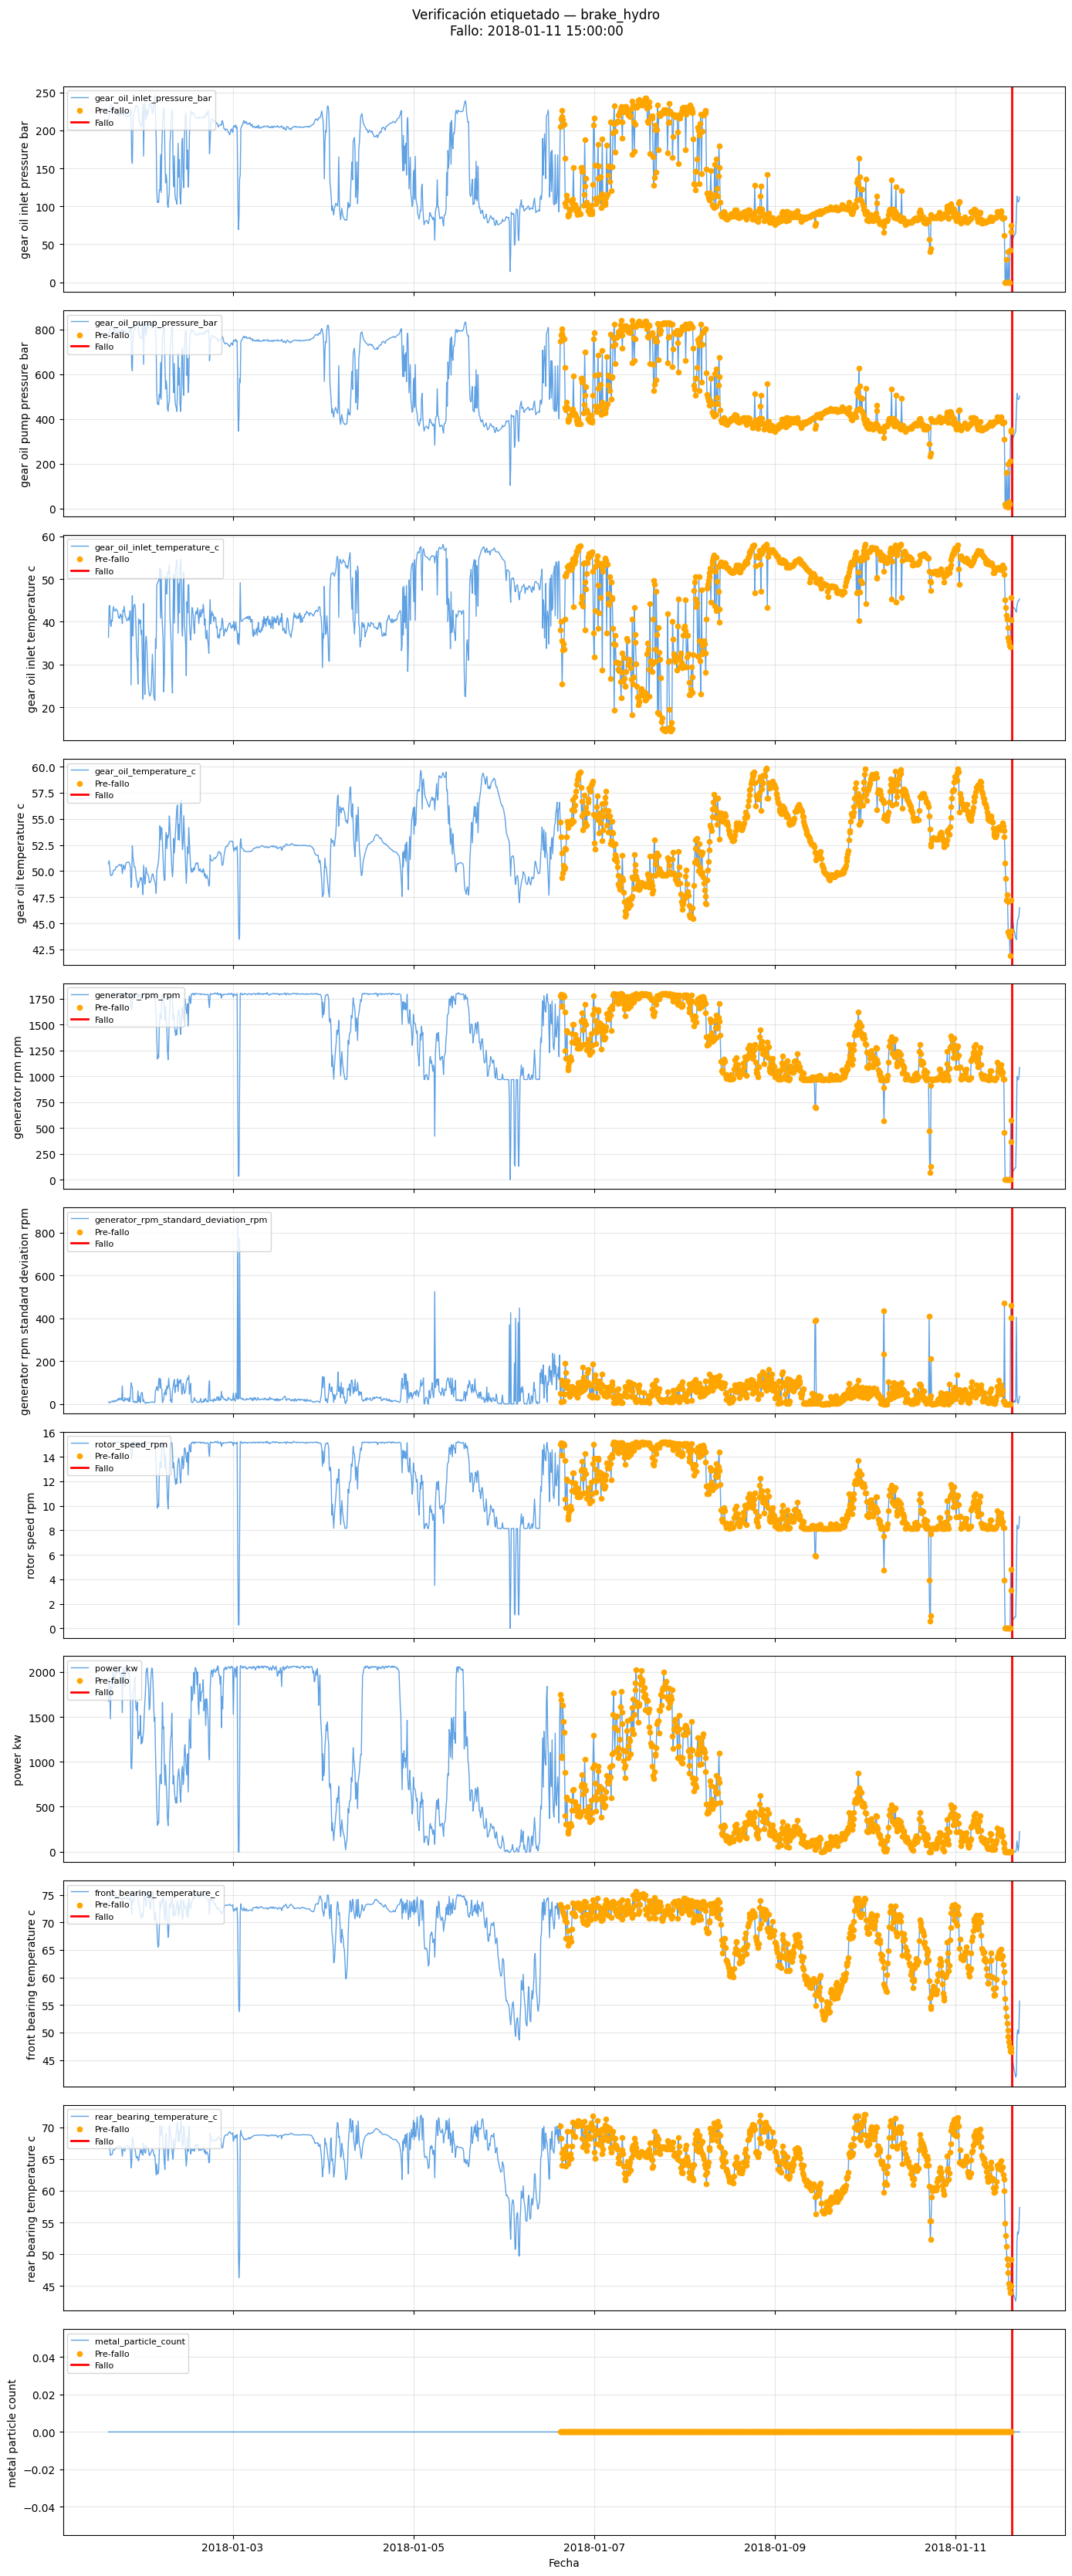


✅ Guardado: ./docs/images/labeling_check_brake_hydro.png
   Sensores: 11
   Pre-fallos: 720 puntos


In [11]:
import os
import pandas as pd
import matplotlib.pyplot as plt

base_dir = os.path.dirname(os.getcwd())

# Cargar datos
telem = pd.read_parquet(os.path.join(base_dir, "data", "silver", "dataset_labeled.parquet"))
targets = pd.read_parquet(os.path.join(base_dir, "data", "silver", "fault_targets_grouped.parquet"))

# ==============================================================================
# CONFIGURACIÓN: familia y sensores
# ==============================================================================
family = "brake_hydro"

SENSORS_BRAKE_HYDRO = [
        "gear_oil_inlet_pressure_bar", "gear_oil_pump_pressure_bar",
        "gear_oil_inlet_temperature_c", "gear_oil_temperature_c",
        "generator_rpm_rpm", "generator_rpm_standard_deviation_rpm",
        "rotor_speed_rpm", "power_kw",
        "front_bearing_temperature_c", "rear_bearing_temperature_c",
        "metal_particle_count",
]

# Crear directorio docs/images si no existe
docs_images_dir = os.path.join(base_dir, "docs", "images")
os.makedirs(docs_images_dir, exist_ok=True)

# ==============================================================================
# TOMAR FALLO DE EJEMPLO
# ==============================================================================
fault_sample = targets[targets["family"] == family]["timestamp"].iloc[0]

print(f"Fallo de ejemplo: {fault_sample}")
print(f"Familia: {family}")

# Ventana de 10 días antes + 2 horas después
window_start = fault_sample - pd.Timedelta(days=10)
window_end = fault_sample + pd.Timedelta(hours=2)

window = telem[(telem["timestamp"] >= window_start) & (telem["timestamp"] <= window_end)].copy()

print(f"Filas en ventana: {len(window)}")
print(f"Filas etiquetadas como pre-fallo: {window[f'is_pre_{family}'].sum()}")

# ==============================================================================
# VISUALIZAR TODOS LOS SENSORES
# ==============================================================================
n_sensors = len(SENSORS_BRAKE_HYDRO )
fig, axes = plt.subplots(n_sensors, 1, figsize=(14, 3 * n_sensors), sharex=True)

if n_sensors == 1:
    axes = [axes]

for idx, sensor in enumerate(SENSORS_BRAKE_HYDRO):
    ax = axes[idx]
    
    if sensor not in window.columns:
        ax.set_title(f"{sensor} — NO ENCONTRADO EN DATASET")
        ax.text(0.5, 0.5, f"Columna '{sensor}' no existe", 
                ha="center", va="center", transform=ax.transAxes)
        continue
    
    # Línea del sensor
    ax.plot(window["timestamp"], window[sensor], 
            color="#378ADD", linewidth=1, alpha=0.8, label=sensor)
    
    # Marcar pre-fallo
    pre_window = window[window[f"is_pre_{family}"]]
    if len(pre_window) > 0:
        ax.scatter(pre_window["timestamp"], pre_window[sensor],
                   color="orange", s=20, label="Pre-fallo", zorder=5)
    
    # Línea del fallo
    ax.axvline(fault_sample, color="red", linewidth=2, label="Fallo")
    
    ax.set_ylabel(sensor.replace("_", " "))
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Fecha")
fig.suptitle(f"Verificación etiquetado — {family}\nFallo: {fault_sample}", 
             fontsize=12, y=1.01)

plt.tight_layout()

# Guardar
output_path = os.path.join(docs_images_dir, f"labeling_check_{family}.png")
plt.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()

rel_path = os.path.relpath(output_path, base_dir)
print(f"\n✅ Guardado: ./{rel_path}")
print(f"   Sensores: {n_sensors}")
print(f"   Pre-fallos: {window[f'is_pre_{family}'].sum()} puntos")

In [12]:
# Guardar dataset con todas las columnas de target
output_path = os.path.join(base_dir, "data", "silver", "dataset_labeled.parquet")
telem.to_parquet(output_path, index=False)

rel_path = os.path.relpath(output_path, base_dir)
print(f"✅ Dataset etiquetado guardado en ./{rel_path}")

# Resumen de columnas creadas
target_cols = [c for c in telem.columns if c.startswith("hours_to_") or c.startswith("is_pre_")]
print(f"\nColumnas target creadas: {len(target_cols)}")
for col in sorted(target_cols):
    print(f"  - {col}")

# Resumen final por familia
print(f"\n{'='*60}")
print("RESUMEN DE ETIQUETADO")
print(f"{'='*60}")
for family in FAULT_FAMILIES.keys():
    n_pre = telem[f"is_pre_{family}"].sum()
    pct = 100 * n_pre / len(telem)
    print(f"{family:12}: {n_pre:>6,} filas pre-fallo ({pct:>5.2f}%)")

KeyboardInterrupt: 